<a href="https://colab.research.google.com/github/chinwejoseph/JDA_NPOWER_CANADA/blob/main/Visualisation_with_seaborn_and_folium_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install pandas
%pip install numpy
%pip install seaborn
%pip install folium

In [2]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [3]:
import requests
import io
import pandas as pd

# URL of the CSV file
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"

# Fetch the data from the URL
response = requests.get(URL)

# Raise an error if the request failed
response.raise_for_status()

# Convert the response content into a readable format for pandas
csv_content = io.StringIO(response.text)

# Read the CSV data into a pandas dataframe
df = pd.read_csv(csv_content)

# Print confirmation
print('Data downloaded and read into a dataframe!')

# Optional: Show the first few rows of the dataframe
print(df.head())

Data downloaded and read into a dataframe!
         Date  Year Month  Recession  Consumer_Confidence  Seasonality_Weight  \
0  1980-01-31  1980   Jan          1               108.24                0.45   
1  1980-01-31  1980   Jan          1               108.24                0.45   
2  1980-01-31  1980   Jan          1               108.24                0.36   
3  1980-01-31  1980   Jan          1               108.24                0.38   
4  1980-02-29  1980   Feb          1                98.75                0.46   

   Price  Advertising_Expenditure  Competition    GDP  Growth_Rate  \
0  27704                   1417.5            7  60.22         0.01   
1  77270                    763.7            7  60.22         0.01   
2  19665                   1417.5            7  60.22         0.01   
3  36986                   1417.5            7  60.22         0.01   
4  26609                   2773.4            4  45.99        -0.31   

   unemployment_rate  Automobile_Sales     Vehicl

In [4]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,2001.520833,0.224432,101.210890,0.737756,41469.506155,2879.743655,6.118845,40.205748,-0.237074,2.441525,3164.160511
std,12.535031,0.417306,10.634092,0.286092,21388.409141,1175.338324,1.964292,16.291271,0.859691,1.108472,3640.137399
min,1980.000000,0.000000,73.900000,0.250000,15001.000000,494.200000,3.000000,12.510000,-4.230000,1.000000,40.000000
25%,1991.000000,0.000000,94.060000,0.500000,22039.000000,1872.000000,4.000000,27.210000,-0.570000,1.600000,923.000000
50%,2002.000000,0.000000,100.800000,0.810000,34957.500000,2883.500000,6.000000,39.420000,-0.005000,2.300000,2381.500000
75%,2012.000000,0.000000,108.320000,0.940000,57418.250000,3902.425000,8.000000,53.862500,0.392500,2.900000,4363.500000
max,2023.000000,1.000000,131.670000,1.500000,79998.000000,4983.000000,9.000000,70.370000,0.820000,6.000000,65645.000000


In [5]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

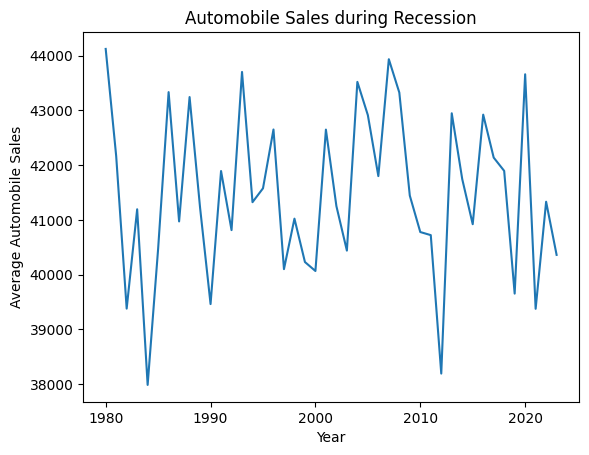

In [6]:
#Develop a Line chart to show Average automobile sales fluctuatipns from year to year
#ticks on x- axis with all the years, to identify the years of recession
#annotation for at least two years of recession
#Title as Automobile Sales during Recession
df.groupby('Year')['Price'].mean().plot(kind='line')
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.title('Automobile Sales during Recession')
plt.show()

In [7]:
# use Seaborn to create a visualization comparing the sales trend per vehicle
# type for a recession period with a non-recession period
df_recession = df[df['Recession'] == 1]

In [8]:
# compare the sales of different vehicle types during a recession and a
# non-recession period and create a visualization for this
df_recession = df[df['Recession'] == 1]
df_non_recession = df[df['Recession'] == 0]

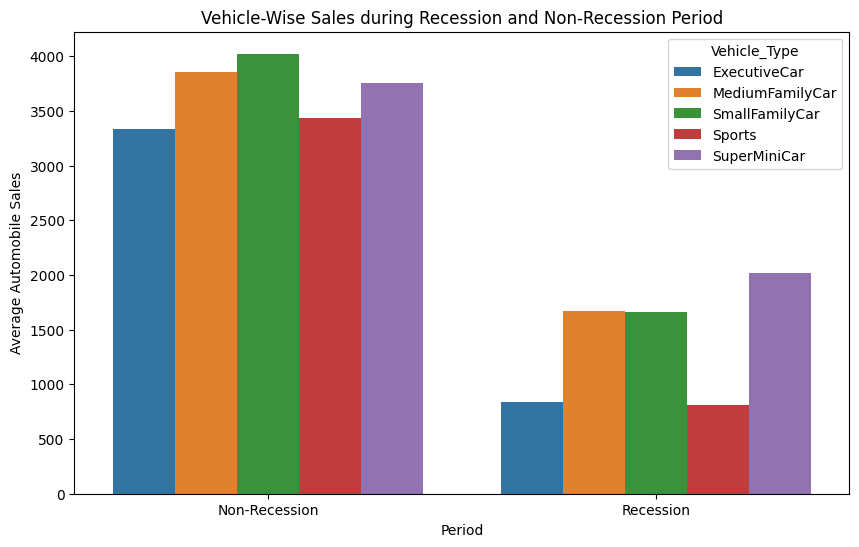

In [10]:
grouped_df = df.groupby(['Recession', 'Vehicle_Type'])['Automobile_Sales'].mean().reset_index()
# Create the grouped bar chart using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Vehicle_Type', data=grouped_df)
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.xlabel('Period')
plt.ylabel('Average Automobile Sales')
plt.title('Vehicle-Wise Sales during Recession and Non-Recession Period')

plt.show()

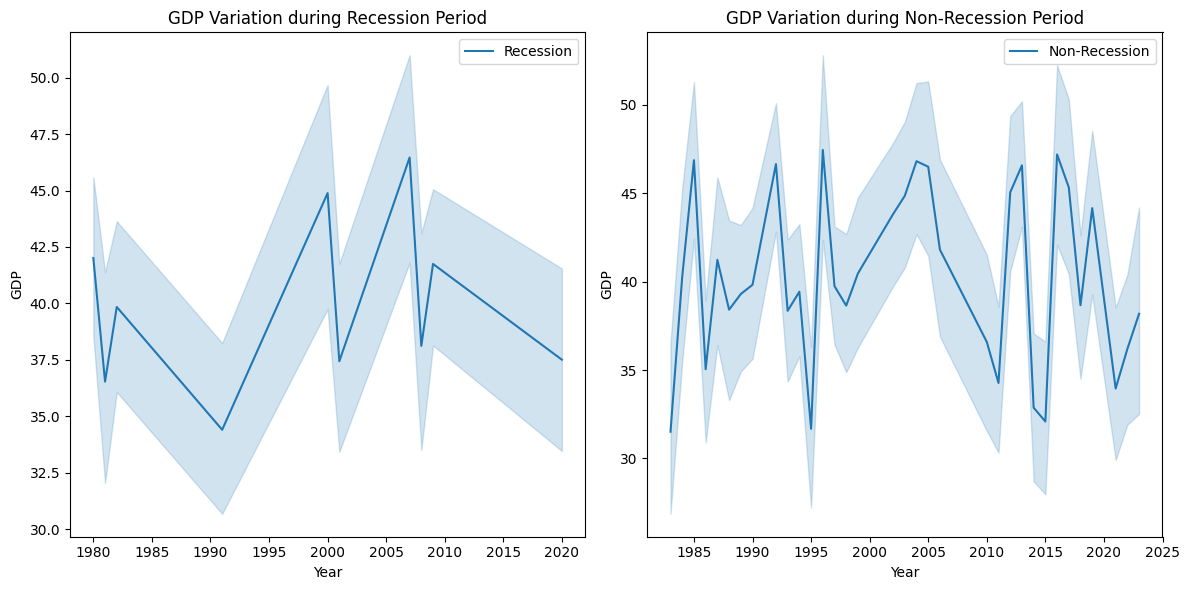

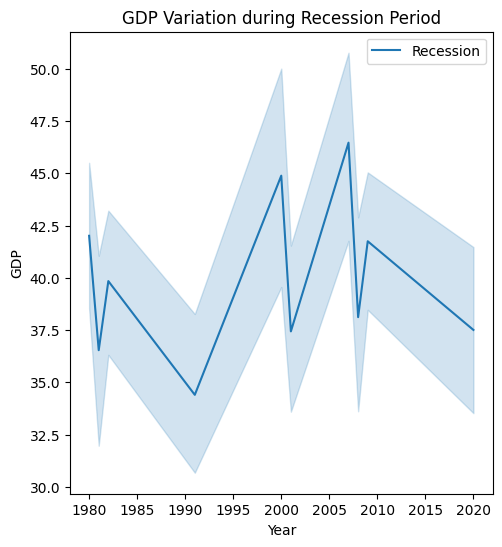

In [11]:
# Use sub plotting to compare the variations in GDP during recession and
# non-recession period by developing line plots for each period
#Create dataframes for recession and non-recession period
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]

#Figure
fig=plt.figure(figsize=(12, 6))

#Create different axes for subploting
ax0 = fig.add_subplot(1, 2, 1) # add subplot 1 (1 row, 2 columns, first plot)
ax1 = fig.add_subplot(1, 2, 2) # add subplot 2 (1 row, 2 columns, second plot).

#plt.subplot(1, 2, 1)
sns.lineplot(x='Year', y='GDP', data=rec_data, label='Recession', ax=ax0)
ax0.set_xlabel('Year')
ax0.set_ylabel('GDP')
ax0.set_title('GDP Variation during Recession Period')

#plt.subplot(1, 2, 2)
sns.lineplot(x='Year', y='GDP', data=non_rec_data, label='Non-Recession', ax=ax1)
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')
ax1.set_title('GDP Variation during Non-Recession Period')

plt.tight_layout()
plt.show()

#------------------------------------------------Alternatively--------------
#Using subplot()
plt.figure(figsize=(12, 6))

#subplot 1
plt.subplot(1, 2, 1)
sns.lineplot(x='Year', y='GDP', data=rec_data, label='Recession')
plt.xlabel('Year')
plt.ylabel('GDP')
plt.title('GDP Variation during Recession Period')
plt.legend()

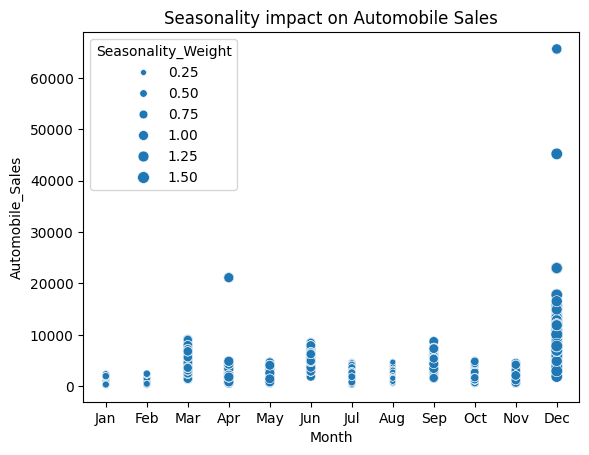

In [13]:
non_rec_data = df[df['Recession'] == 0]

size=non_rec_data['Seasonality_Weight'] #for bubble effect

sns.scatterplot(data=non_rec_data, x='Month', y='Automobile_Sales', size=size)

#you can further include hue='Seasonality_Weight', legend=False)

plt.xlabel('Month')
plt.ylabel('Automobile_Sales')
plt.title('Seasonality impact on Automobile Sales')

plt.show()

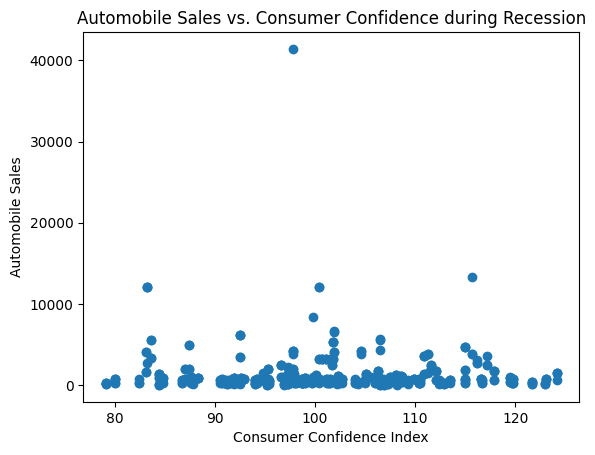

In [15]:
#Create dataframes for recession and non-recession period
rec_data = df[df['Recession'] == 1]
plt.scatter(rec_data['Consumer_Confidence'], rec_data['Automobile_Sales'])

plt.xlabel('Consumer Confidence Index')
plt.ylabel('Automobile Sales')
plt.title('Automobile Sales vs. Consumer Confidence during Recession')
plt.show()

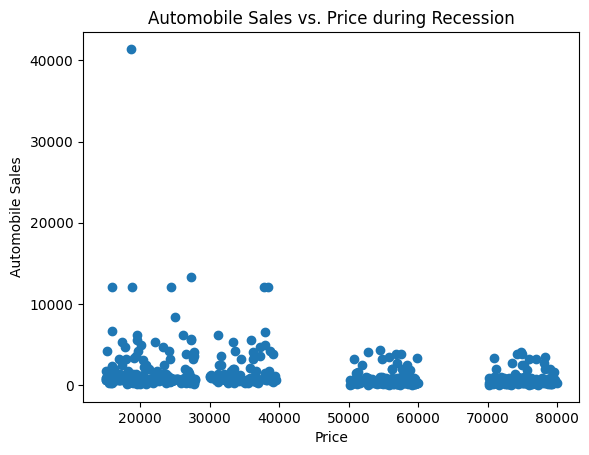

In [17]:
#Create dataframes for recession and non-recession period
rec_data = df[df['Recession'] == 1]
plt.scatter(rec_data['Price'], rec_data['Automobile_Sales'])

plt.xlabel('Price')
plt.ylabel('Automobile Sales')
plt.title('Automobile Sales vs. Price during Recession')
plt.show()

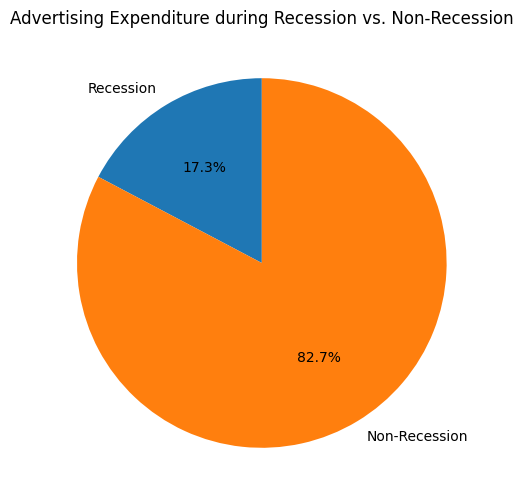

In [19]:
# Filter the data
Rdata = df[df['Recession'] == 1]
NRdata = df[df['Recession'] == 0]

# Calculate the total advertising expenditure for both periods
RAtotal = Rdata['Advertising_Expenditure'].sum()
NRAtotal = NRdata['Advertising_Expenditure'].sum()

# Create a pie chart for the advertising expenditure
plt.figure(figsize=(8, 6))

labels = ['Recession', 'Non-Recession']
sizes = [RAtotal, NRAtotal]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Advertising Expenditure during Recession vs. Non-Recession')

plt.show()

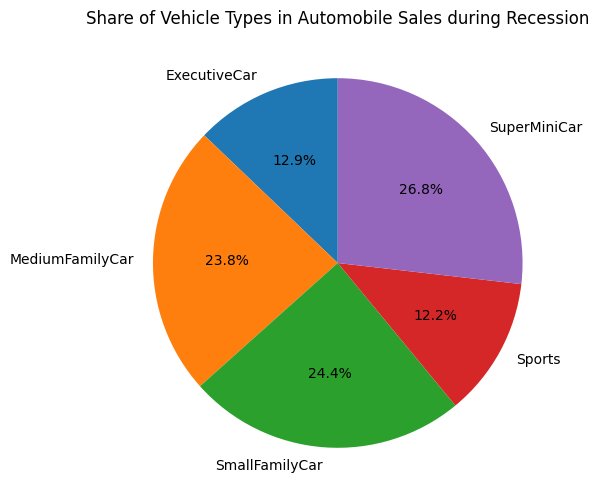

In [21]:
# Filter the data
Rdata = df[df['Recession'] == 1]

# Calculate the sales volume by vehicle type during recessions
VTexpenditure = Rdata.groupby('Vehicle_Type')['Automobile_Sales'].sum()

# Create a pie chart for the share of each vehicle type in total expenditure during recessions
plt.figure(figsize=(10, 6))

labels = VTexpenditure.index
sizes = VTexpenditure.values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Share of Vehicle Types in Automobile Sales during Recession')

plt.show()

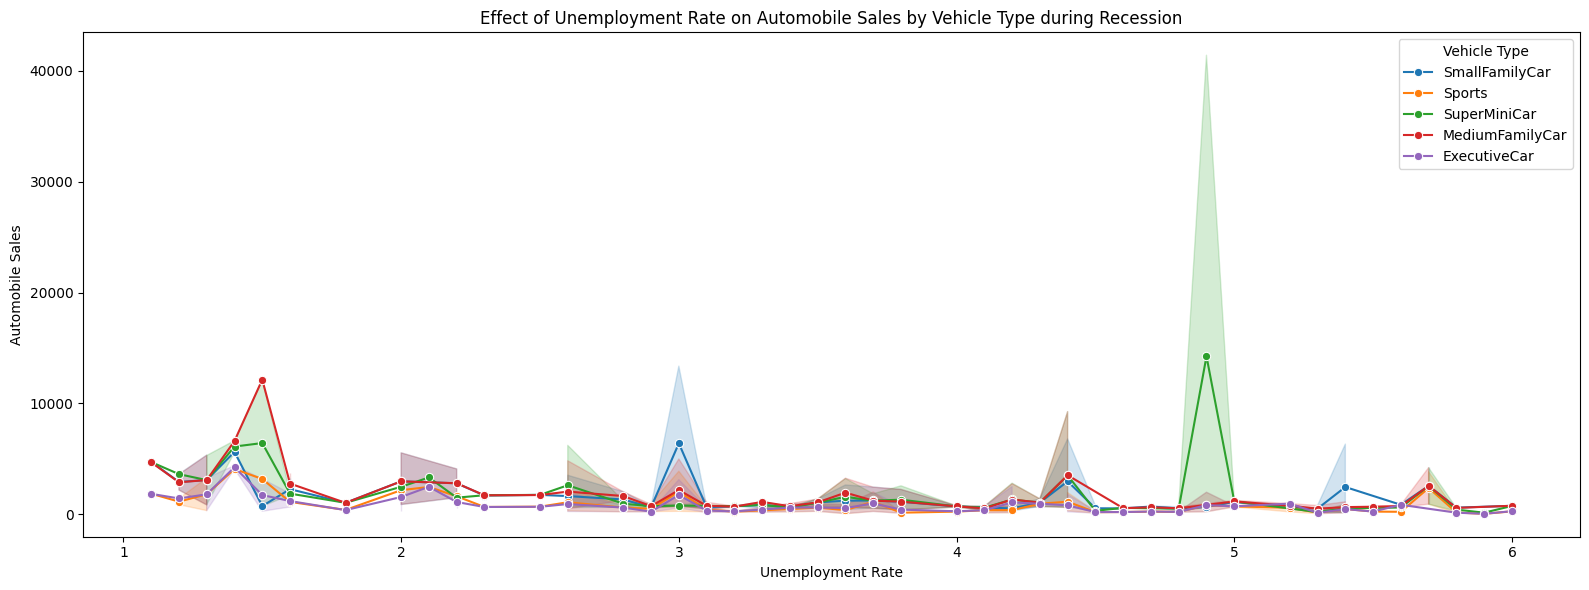

In [23]:
# Assuming 'df' is your dataset
df_rec = df[df['Recession'] == 1]

# Set figure size
plt.figure(figsize=(16, 6))

# Create line plot showing effect of unemployment rate on automobile sales, by vehicle type
sns.lineplot(
    data=df_rec,
    x='unemployment_rate',               # Replace with unemployment rate column (e.g., 'unemployment_rate')
    y='Automobile_Sales',               # Replace with automobile sales column (e.g., 'Automobile_Sales')
    hue='Vehicle_Type',             # Replace with vehicle type column (e.g., 'Vehicle_Type')
    marker='o'
)

# Customize labels, legend, and title
plt.title('Effect of Unemployment Rate on Automobile Sales by Vehicle Type during Recession')
plt.xlabel('Unemployment Rate')
plt.ylabel('Automobile Sales')
plt.legend(title='Vehicle Type')

# Show plot
plt.tight_layout()
plt.show()